In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Book1 (3).csv')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

# 1. Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
# df[~(df['Unnamed: 2'].isnull())]

In [6]:
df.isnull().sum()/df.shape[0]*100

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64

In [7]:
# dropping last 3 columns
df=df.iloc[:,0:2]
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [9]:
5572-403

5169

In [10]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()
df['target']=le.fit_transform(df['target'])

In [13]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
5572-403

5169

In [16]:
df['text'].nunique()

5169

In [17]:
# check for duplicates
df.duplicated().sum()

np.int64(403)

In [18]:
# remove duplicates
df=df.drop_duplicates(keep='first')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
5572-403

5169

In [21]:
df.shape

(5169, 2)

# 2. EDA (Exploratory Data Analysis)

In [22]:

# ! pip install nltk

In [23]:
import nltk

In [24]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Sai\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [25]:
# counting the number of characters in an sms
df['num_characters']=df['text'].apply(len)

In [26]:
df

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [27]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [28]:
nltk.word_tokenize('Hello i am deep')

['Hello', 'i', 'am', 'deep']

In [29]:
# num of words
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [30]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [31]:
nltk.sent_tokenize('Hello How are you ? i may fine')

['Hello How are you ?', 'i may fine']

In [32]:
# number of sentences
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [33]:
df

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [34]:
df.iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
df[df['num_characters']==df['num_characters'].min()]

,target,text,num_characters,num_words,num_sentences
1924,0,Ok,2,1,1


In [36]:
df[df['num_characters']==df['num_characters'].max()]

,target,text,num_characters,num_words,num_sentences
1084,0,For me the love should start with attraction.i...,910,175,1


In [37]:
# ham messages (Not spam)
df[df['target']==0].iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [38]:
# spam messages
df[df['target']==1].iloc[:,2:].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# df[df['target']==0].iloc[:,2]

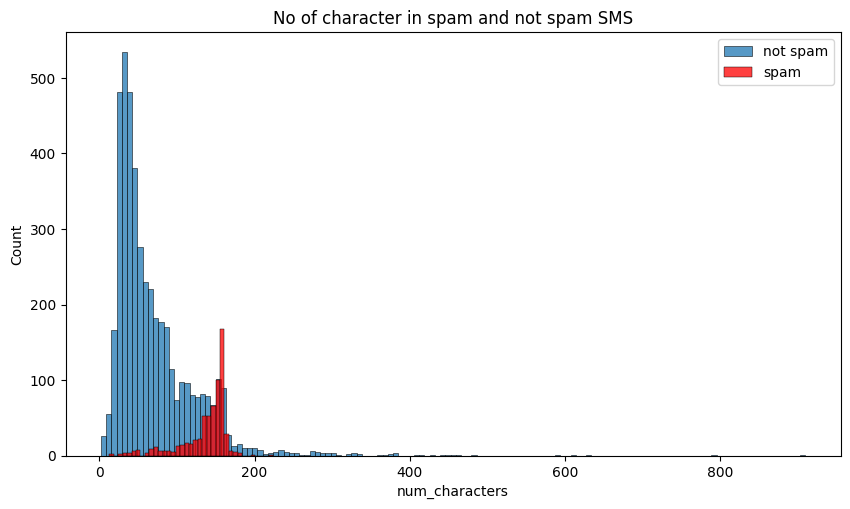

In [41]:
plt.figure(figsize=(10,5.5))
plt.title('No of character in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,2],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,2],color='red',label='spam')
plt.legend()
plt.show()


**aapke jo not spam messages hai usmein jo characters use ho rhe h woh zaadaa hai**


 **where as aapke jo spam messages has usmein characters thode kamm hai**

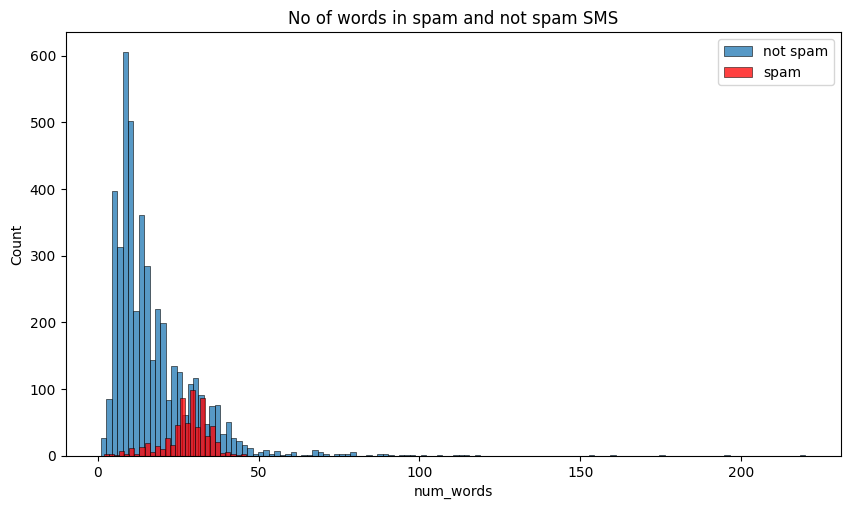

In [42]:
plt.figure(figsize=(10,5.5))
plt.title('No of words in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,3],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,3],color='red',label='spam')
plt.legend()
plt.show()



**mostly  spam messages kam word se millkar bnte hai**

**and not spam messages zaadaaa words se millkar bnte hai**

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [45]:
num_rows=df.select_dtypes(include=np.number)
num_rows

,target,num_characters,num_words,num_sentences
0,0,111,24,2
1,0,29,8,2
2,1,155,37,2
3,0,49,13,1
4,0,61,15,1
...,...,...,...,...
5567,1,161,35,4
5568,0,37,9,1
5569,0,57,15,2
5570,0,125,27,1


In [46]:
import seaborn as sns

<Axes: >

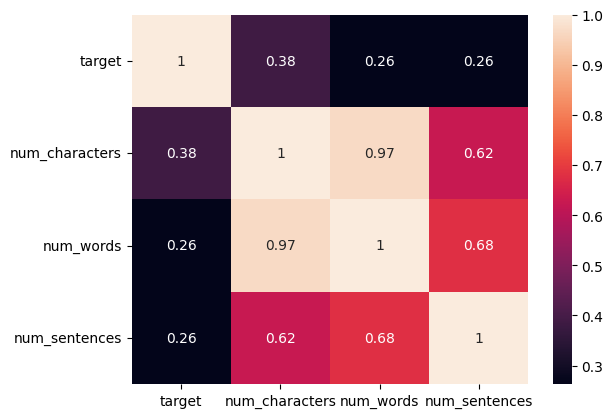

In [47]:
sns.heatmap(num_rows.corr(),annot=True)

**Apna target jo hai num_character pr 0.38 ka correlation hai**


**mean jitne zaaadaa aapke character badhte hai toh 1 hone ka tendency bhi badhta hai mean spam**

**after looking this heatmap isee that here is a high multicollinearity so i will select only 1 column**

# Data Preprocessing
- Lower Case
- Tokenization
- Removing Special Characters
- Removing Stop words & punctuations
- Stemming

In [48]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [49]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [50]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [51]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('walkking')

'walk'

In [52]:
def transform_text(text):
    text=text.lower()# converting in lower case
    # print(text)
    text=nltk.word_tokenize(text)# splitting into words
    # print(text)
    # removing special characters
    L=[]
    for i in text:
        if i.isalnum():
            L.append(i)
    # print(L)
    
# # # #     # removing stop words and punctuation marks
    text=L.copy()
    L.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            L.append(i)
    # print(L)
# # # #     # applying stemming
    text=L.copy()
    L.clear()
    for i in text:
        L.append(ps.stem(i))
    # print(L)
        
    return " ".join(L)

In [53]:
transform_text('helLo Deepanshu i am WALKING ? Are you ^ joInning me.')

'hello deepanshu walk join'

In [54]:
# import string
# string.punctuation

In [55]:
# stopwords.words('english')

In [56]:
transform_text('helLo i am WALKING ? Are you ^ joinning me.')

'hello walk join'

In [57]:
# transform_text('i am enjoying this FDP on Machine Learning ? How about you.')

In [58]:
# testing the function
# transform_text(df['text'][1300])

In [59]:
df['transformed_text']=df['text'].apply(transform_text)

In [60]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [61]:
# ! pip install WordCloud

In [62]:
from wordcloud import WordCloud


In [63]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')


In [64]:
df[df['target']==1]

,target,text,num_characters,num_words,num_sentences,transformed_text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4,freemsg hey darl 3 week word back like fun sti...
8,1,WINNER!! As a valued network customer you have...,158,32,5,winner valu network custom select receivea pri...
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3,mobil 11 month u r entitl updat latest colour ...
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3,six chanc win cash 100 pound txt csh11 send co...
...,...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3,want explicit sex 30 sec ring 02073162414 cost...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,38,6,ask 3mobil 0870 chatlin inclu free min india c...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5,contract mobil 11 mnth latest motorola nokia e...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1,remind o2 get pound free call credit detail gr...


In [65]:
df

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [66]:
# corpus
df[df['target']==1]['transformed_text'].str.cat(sep=" ")

'free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18 freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030 six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub use credit click wap link next txt messag click http england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq thank subscript rington uk mobil charg pleas confirm repli ye repli charg 07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow sm ac sptv new jersey devil detroit red w

In [67]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

In [68]:
import matplotlib.pyplot as plt

In [69]:
plt.figure(figsize=(12,12),dpi=1000)
plt.imshow(spam_wc);

In [70]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep='" "'))

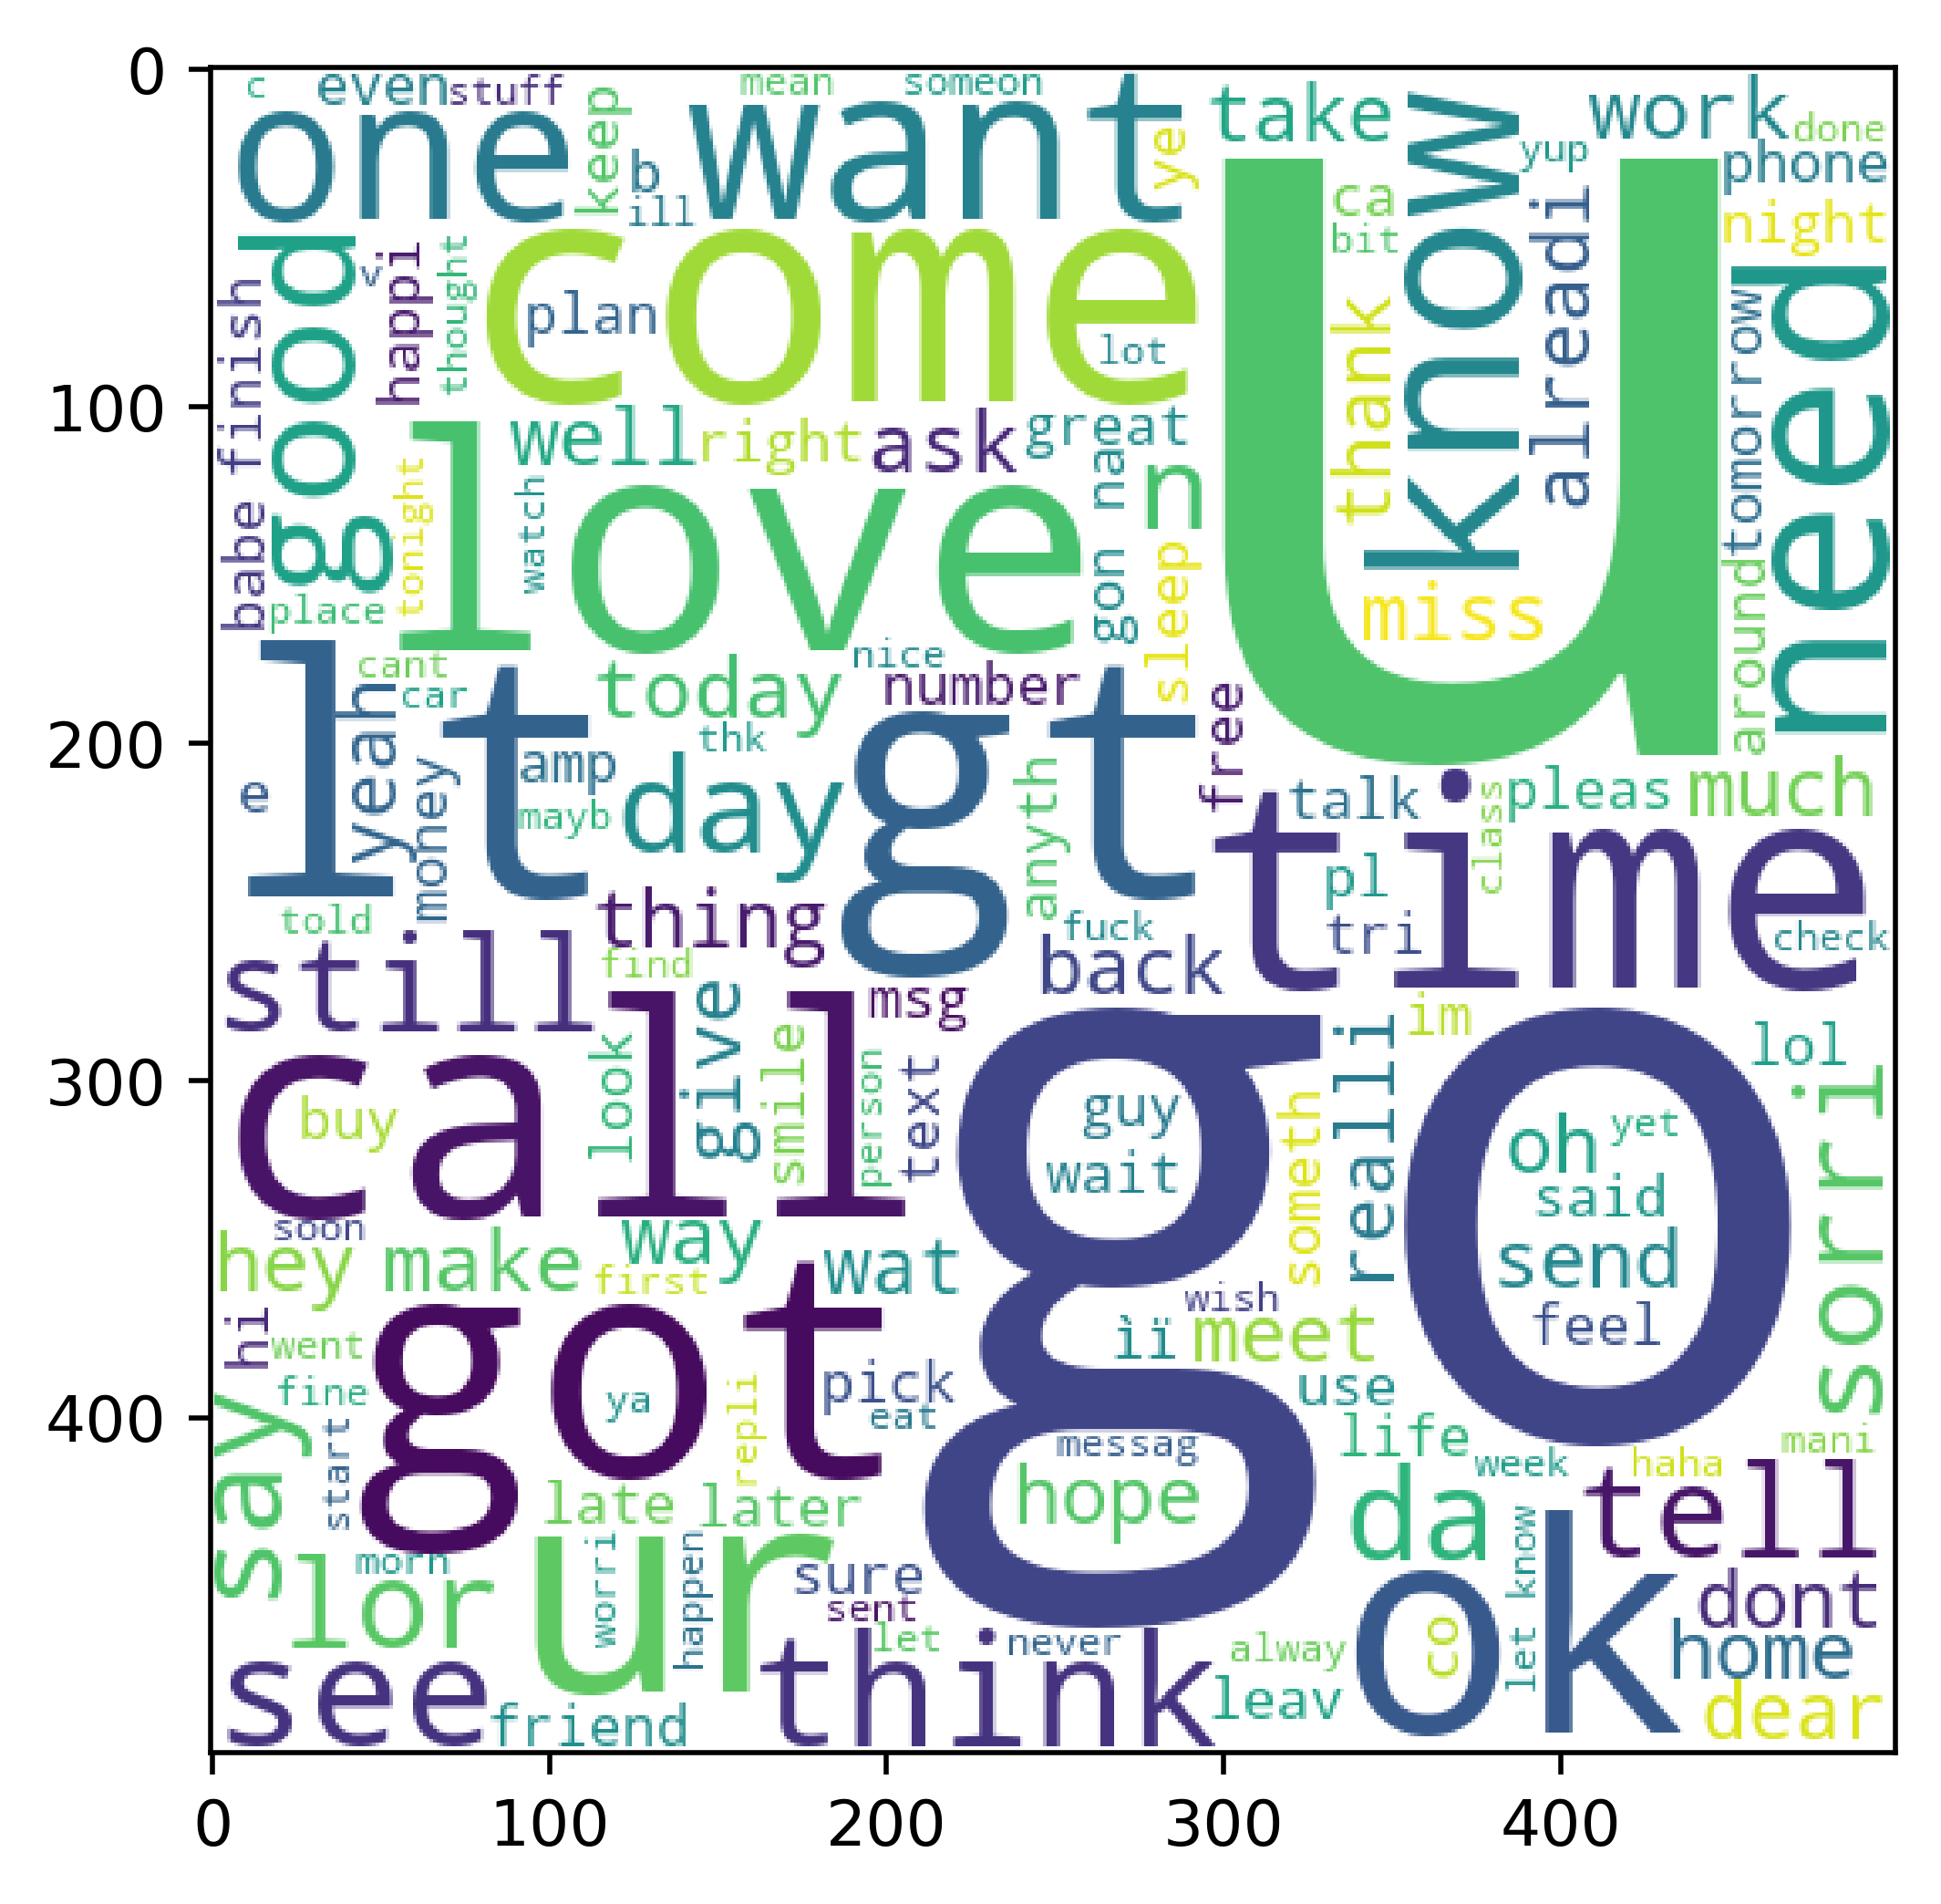

In [71]:
plt.figure(dpi=500)
plt.imshow(ham_wc);

In [72]:
# displaying the top 30 words in spam sms

In [73]:
df[df['target']==1]['transformed_text'].tolist()

['free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info',
 'urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 '07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow',
 '

In [74]:
# df[df['target']==1]['transformed_text'].tolist()

In [75]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        
print(spam_corpus)      

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click',

In [76]:
# spam_corpus

In [77]:
# for counting the words
from collections import Counter


In [78]:
spam_df=pd.DataFrame(Counter(spam_corpus).most_common()).rename(columns={0:'words',1:'count'})
spam_df

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
...,...,...
2217,shit,1
2218,bailiff,1
2219,hous,1
2220,087187272008,1


In [79]:
import seaborn as sns

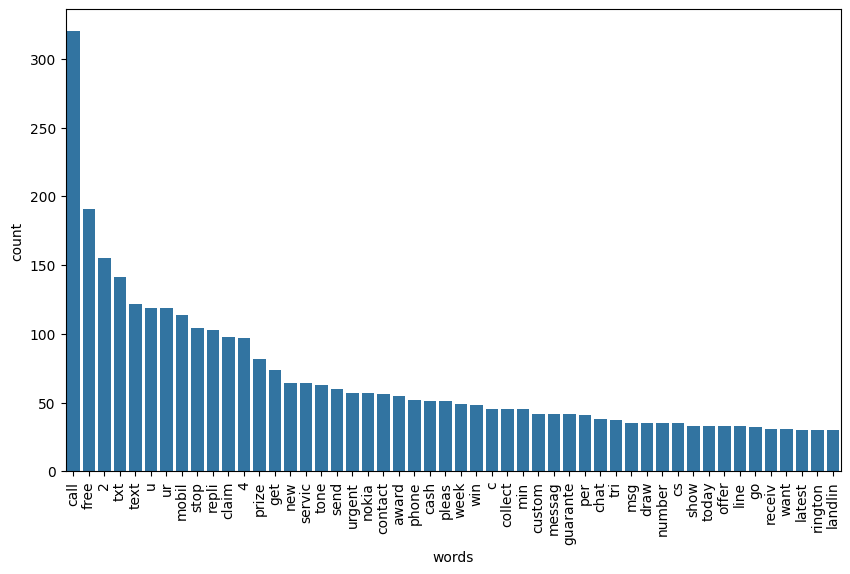

In [80]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=spam_df.head(50))
plt.xticks(rotation='vertical')
plt.show()

In [81]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [82]:
# ham_corpus


In [83]:
ham_df=pd.DataFrame(Counter(ham_corpus).most_common()).rename(columns={0:'words',1:'count'})
ham_df

,words,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
...,...,...
5385,nmde,1
5386,dump,1
5387,heap,1
5388,salesman,1


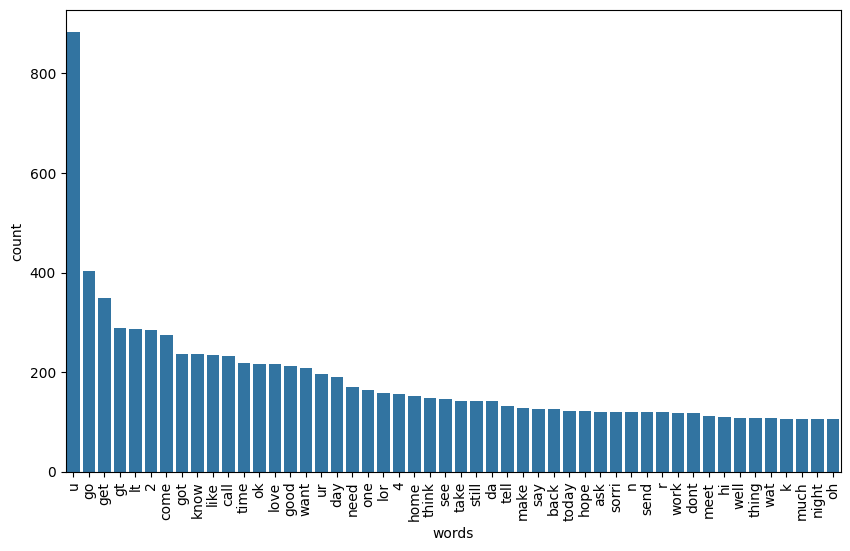

In [84]:
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=ham_df.head(50))
plt.xticks(rotation='vertical')
plt.show()

# 4. Feature Engineering

In [85]:
# df

In [86]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
# cv = CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [87]:
X=tfidf.fit_transform(df['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [88]:
X.shape

(5169, 3000)

In [89]:
y=df['target'].values

In [90]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [91]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

# 5. Model Building

In [94]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [95]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [96]:
gnb.fit(x_train,y_train)
y_pred_test1=gnb.predict(x_test)
y_pred_train1=gnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test1))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train1))
print('Precision_Score',precision_score(y_train,y_pred_train1))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train1))



Testing Accuracy 0.874274661508704
Trainning_Accuracy 0.8940749697702539
Precision_Score 0.540398740818468
Confusion_matrix
 [[3182  438]
 [   0  515]]


In [97]:
# performance check metrics for regression -----------r2_score
# performance check metrics for classification--------accuracy_score (confusion metrics)
#                                                     (TP+TN)/(TP+FP+TN+FN)

In [98]:
mnb.fit(x_train,y_train)
y_pred_test2=mnb.predict(x_test)
y_pred_train2=mnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test2))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train2))
print('Precision_Score',precision_score(y_train,y_pred_train2))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train2))



Testing Accuracy 0.9709864603481625
Trainning_Accuracy 0.9779927448609431
Precision_Score 0.9953271028037384
Confusion_matrix
 [[3618    2]
 [  89  426]]


In [99]:
bnb.fit(x_train,y_train)
y_pred_test3=bnb.predict(x_test)
y_pred_train3=bnb.predict(x_train)
print('Testing Accuracy',accuracy_score(y_test,y_pred_test3))
print('Trainning_Accuracy',accuracy_score(y_train,y_pred_train3))
print('Precision_Score',precision_score(y_train,y_pred_train3))
print('Confusion_matrix\n',confusion_matrix(y_train,y_pred_train3))



Testing Accuracy 0.9835589941972921
Trainning_Accuracy 0.9852478839177751
Precision_Score 0.9956331877729258
Confusion_matrix
 [[3618    2]
 [  59  456]]


In [100]:
svc = SVC()
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [101]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [102]:
# clfs.items()

In [103]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred_test = clf.predict(X_test)
    y_pred_train = clf.predict(X_train)

    accuracy_test = accuracy_score(y_test,y_pred_test)
    accuracy_train = accuracy_score(y_train,y_pred_train)

    
    return accuracy_test,accuracy_train

In [104]:
train_classifier(SVC(),x_train,y_train,x_test,y_test)

(0.9738878143133463, 0.9961305925030229)

In [105]:
accuracy_train1 = []
accuracy_test1 = []

precision_scores = []

for name,clf in clfs.items():
    
    accuracy_test,accuracy_train= train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Training Accuracy - ",accuracy_train)
    print("Testing Accuracy - ",accuracy_test)
    # print("Precision - ",precision)
    
    accuracy_train1.append(accuracy_train)
    accuracy_test1.append(accuracy_test)

    # precision_scores.append(precision)

For  SVC
Training Accuracy -  0.9961305925030229
Testing Accuracy -  0.9738878143133463
For  KN
Training Accuracy -  0.924788391777509
Testing Accuracy -  0.9052224371373307
For  NB
Training Accuracy -  0.9779927448609431
Testing Accuracy -  0.9709864603481625
For  DT
Training Accuracy -  0.9499395405078598
Testing Accuracy -  0.9332688588007737
For  LR
Training Accuracy -  0.9651753325272068
Testing Accuracy -  0.9545454545454546
For  RF
Training Accuracy -  0.9995163240628778
Testing Accuracy -  0.9738878143133463
For  AdaBoost
Training Accuracy -  0.9250302297460702
Testing Accuracy -  0.9216634429400387
For  BgC
Training Accuracy -  0.9992744860943168
Testing Accuracy -  0.9584139264990329
For  ETC
Training Accuracy -  0.9995163240628778
Testing Accuracy -  0.9748549323017408
For  GBDT
Training Accuracy -  0.9675937122128174
Testing Accuracy -  0.9506769825918762
For  xgb
Training Accuracy -  0.9845223700120919
Testing Accuracy -  0.9680851063829787


In [106]:
performance_df =pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_train':accuracy_train1,'Accuracy_test':accuracy_test1})
performance_df.sort_values(by='Accuracy_test',ascending=False)

,Algorithm,Accuracy_train,Accuracy_test
8,ETC,0.999516,0.974855
5,RF,0.999516,0.973888
0,SVC,0.996131,0.973888
2,NB,0.977993,0.970986
10,xgb,0.984522,0.968085
7,BgC,0.999274,0.958414
4,LR,0.965175,0.954545
9,GBDT,0.967594,0.950677
3,DT,0.949940,0.933269
6,AdaBoost,0.925030,0.921663


In [107]:
performance_df.sort_values('Accuracy_test', ascending=False)

,Algorithm,Accuracy_train,Accuracy_test
8,ETC,0.999516,0.974855
5,RF,0.999516,0.973888
0,SVC,0.996131,0.973888
2,NB,0.977993,0.970986
10,xgb,0.984522,0.968085
7,BgC,0.999274,0.958414
4,LR,0.965175,0.954545
9,GBDT,0.967594,0.950677
3,DT,0.949940,0.933269
6,AdaBoost,0.925030,0.921663


In [108]:
# improving model_performances
# 1. Change the max_features parameter of TfIdf


In [109]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))